**Name: Leonardus Hasan**

**NIM: 2802553480**

**Class: LA09**

**Major: Data Science**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier, plot_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, make_scorer, recall_score
import re

In [ ]:
df = pd.read_csv("Credis_Score_Dataset_B.csv")

<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:1: SyntaxWarning: invalid escape sequence '\C'
C:\Users\LEO\AppData\Local\Temp\ipykernel_8172\3217828985.py:1: SyntaxWarning: invalid escape sequence '\C'
  df = pd.read_csv("Number 1 Classification\Credis_Score_Dataset_B.csv")


## EXPLORATORY DATA ANALYSIS

In [3]:
df.tail()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
49995,0x993b,CUS_0x710e,June,Papadimasx,44,840-65-9735,Doctor,41678.65,3672.220833,2,...,Good,1209.49,37.547392,21 Years and 1 Months,No,76.058271,146.10019412347015,Low_spent_Small_value_payments,435.0636180428778,Standard
49996,0x22db9,CUS_0x457e,August,Flitterq,54_,656-83-9494,Journalist,59343.12,4919.260000,7,...,Standard,9.32,39.561824,21 Years and 3 Months,Yes,0.000000,123.45654719780038,High_spent_Medium_value_payments,618.4694528021996,Standard
49997,0x20419,CUS_0x36e1,August,Gellero,35,132-77-4921,Journalist,20364.57,1626.047500,6,...,Standard,2500.04,27.576478,9 Years and 8 Months,Yes,26.168109,92.51897591535379,High_spent_Small_value_payments,303.9176651596068,Standard
49998,0x1a30,CUS_0x3861,March,Fiona Ortizx,-500,212-32-2085,Engineer,17992.775,1769.397917,3,...,_,565.22,23.136824,19 Years and 1 Months,No,0.000000,95.65646110813336,High_spent_Small_value_payments,341.28333055853335,Poor
49999,0x1605c,CUS_0x944,July,Anurag Kotokyn,42,992-65-1613,Manager,119402.64,9679.220000,8,...,Standard,766.15,36.895288,29 Years and 7 Months,No,176.157491,1173.0898776792633,!@9#%8,NaN,Standard


In [4]:
pd.set_option('display.max_columns', None)
df.describe(include = 'all')

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
count,50000,50000,50000,45058,50000,50000,50000,50000,42512.000000,50000.000000,50000.000000,50000.000000,50000,44324,50000.000000,46398,50000,48993.000000,50000,50000,50000.000000,45536,50000,50000.000000,47773,50000,49389,50000
unique,50000,12443,8,10056,995,12415,16,15954,NaN,NaN,NaN,NaN,225,6236,NaN,419,3931,NaN,4,12646,NaN,403,3,NaN,45576,7,49386,3
top,0xc765,CUS_0x12cb,January,Deepa Seetharamanm,31,#F%$D@*&8,_______,17816.75,NaN,NaN,NaN,NaN,3,Not Specified,NaN,19,_,NaN,Standard,1075.37,NaN,15 Years and 10 Months,Yes,NaN,__10000__,Low_spent_Small_value_payments,__-333333333333333333333333333__,Standard
freq,1,8,6338,29,1488,2805,3481,10,NaN,NaN,NaN,NaN,7269,730,NaN,2719,1028,NaN,18223,13,NaN,231,26061,NaN,2126,12737,4,26587
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4203.216405,17.086080,22.957140,74.235060,NaN,NaN,21.042240,NaN,NaN,27.820995,NaN,NaN,32.322989,NaN,NaN,1418.523068,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3183.003079,118.287242,130.551021,473.234671,NaN,NaN,14.875604,NaN,NaN,194.189624,NaN,NaN,5.121291,NaN,NaN,8377.047806,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,303.645417,-1.000000,0.000000,1.000000,NaN,NaN,-5.000000,NaN,NaN,0.000000,NaN,NaN,20.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1630.113333,3.000000,4.000000,8.000000,NaN,NaN,10.000000,NaN,NaN,3.000000,NaN,NaN,28.083070,NaN,NaN,30.181528,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3105.010000,6.000000,5.000000,13.000000,NaN,NaN,18.000000,NaN,NaN,6.000000,NaN,NaN,32.342262,NaN,NaN,69.337833,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5974.963333,7.000000,7.000000,20.000000,NaN,NaN,28.000000,NaN,NaN,9.000000,NaN,NaN,36.536895,NaN,NaN,160.992411,NaN,NaN,NaN,NaN


1. There are some unique values in this data, for example: ID, Customer_ID, Name, and SSN. Because of that, I'll not use those columns to take part for modelling.
2. There are some inconsistent data in age (e.g: 25_) and there are ages that equal more than 100, so it has to be handled. The solutions are take out the "_" part and ages
3. Month will not be used for modelling because it is not indicating how trustworthy the person is by what time in month does a person do the inquiries.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        50000 non-null  object 
 1   Customer_ID               50000 non-null  object 
 2   Month                     50000 non-null  object 
 3   Name                      45058 non-null  object 
 4   Age                       50000 non-null  object 
 5   SSN                       50000 non-null  object 
 6   Occupation                50000 non-null  object 
 7   Annual_Income             50000 non-null  object 
 8   Monthly_Inhand_Salary     42512 non-null  float64
 9   Num_Bank_Accounts         50000 non-null  int64  
 10  Num_Credit_Card           50000 non-null  int64  
 11  Interest_Rate             50000 non-null  int64  
 12  Num_of_Loan               50000 non-null  object 
 13  Type_of_Loan              44324 non-null  object 
 14  Delay_

From this data, I found out that there are some columns that have to be cast typed into integer or double so they could be use for modelling. Such as: Month, Occupation, Annual_Income, Num_of_Loan, Num_of_Delayed_Payment, Changed_Credit_Limit, Credit_Mix (Encode), Outstanding_Debt, Credit_History_Age, Payment_of_Min_Amount (Encode), Amount_invested_monthly, Payment_Behaviour (Encode), and Monthly_Balance.

There are many object columns in this dataset. Therefore, I have to change it to numeric so it could be used for modelling.

In [6]:
df.isna().sum()

ID                             0
Customer_ID                    0
Month                          0
Name                        4942
Age                            0
SSN                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary       7488
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Type_of_Loan                5676
Delay_from_due_date            0
Num_of_Delayed_Payment      3602
Changed_Credit_Limit           0
Num_Credit_Inquiries        1007
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age          4464
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly     2227
Payment_Behaviour              0
Monthly_Balance              611
Credit_Score                   0
dtype: int64

In [7]:
df.duplicated().sum()

0

There are null values in some columns and no duplicates. To handle the missing value, I have to check the condition per columns.

In [8]:
anomaly_column = ['Amount_invested_monthly', 'Monthly_Balance']

for c in anomaly_column:
    print(df[c].value_counts())

Amount_invested_monthly
__10000__             2126
0.0                     73
133.3373934079426        1
99.24335616672032        1
186.1438885878324        1
                      ... 
574.5456606327708        1
35.958170687876475       1
53.55506806642994        1
64.54744172252826        1
1173.0898776792633       1
Name: count, Length: 45576, dtype: int64
Monthly_Balance
__-333333333333333333333333333__    4
248.55092985209012                  1
407.7014027717323                   1
338.00797908825865                  1
653.5650110760414                   1
                                   ..
260.2477887046783                   1
301.3362175961811                   1
239.47530437792324                  1
258.4391913020734                   1
341.28333055853335                  1
Name: count, Length: 49386, dtype: int64


From the dataset, I found that there are inconsistent value which are `__-333333333333333333333333333__` and `__10000__`. These values means nothing, so I'll change it as none and then impute it with median.

In [9]:
obj_col = df.select_dtypes(include=object)

for i in obj_col:
    print(df[i].value_counts())
    print("\n")

ID
0xc765     1
0x15099    1
0x1667a    1
0x1763e    1
0xacab     1
          ..
0x864d     1
0xce16     1
0x1c4c4    1
0x11b7d    1
0x1605c    1
Name: count, Length: 50000, dtype: int64




Customer_ID
CUS_0x12cb    8
CUS_0x8e2     8
CUS_0x3bbf    8
CUS_0x79c1    8
CUS_0x55e6    8
             ..
CUS_0x7641    1
CUS_0x3cfa    1
CUS_0x922f    1
CUS_0x952a    1
CUS_0x4401    1
Name: count, Length: 12443, dtype: int64


Month
January     6338
February    6263
March       6258
August      6244
July        6243
June        6239
April       6219
May         6196
Name: count, dtype: int64


Name
Deepa Seetharamanm    29
Vaughanl              24
Nate Raymondw         24
Jonathan Stempelr     23
Raymondr              23
                      ..
Jessica Toonkels       1
ill Berkrotg           1
Alisonn                1
Ferrarot               1
Ashleyp                1
Name: count, Length: 10056, dtype: int64


Age
31      1488
28      1427
38      1426
26      1393
32      1391
        ... 
6754       1
6674       1
6435       1
2334       1
7868       1
Name: count, Length: 995, dtype: int64


SSN
#F%$D@*&8      2805
397-17-7108       8
781-21-4555       8
159-88-1119       8
1

In column 'Monthly_Balance', there are an inconsistent value "!@9#%8". Because this is a categorical variable, I'll replace it with none and impute with mode after splitting the data.

In [10]:
df.loc[df["Num_of_Loan"].str.contains(r"[-_]"), ["Num_of_Loan", "Type_of_Loan"]]

,Num_of_Loan,Type_of_Loan
0,-100,"Personal Loan, and Credit-Builder Loan"
18,-100,"Personal Loan, Home Equity Loan, Credit-Builde..."
28,-100,"Payday Loan, Student Loan, and Credit-Builder ..."
45,4_,"Student Loan, Credit-Builder Loan, Debt Consol..."
55,1_,Personal Loan
...,...,...
49900,2_,"Personal Loan, and Student Loan"
49947,4_,"Payday Loan, Auto Loan, Personal Loan, and Cre..."
49951,-100,"Student Loan, and Payday Loan"
49962,-100,"Debt Consolidation Loan, Debt Consolidation Lo..."


There are some values that have '_' and minus value (-100). The best practice is to remove the underscore from the number. After that, recount the 'Type_of_Loan' and impute it into Num_of_Loan so that the number of loan in column Num_of_Loan is the same as the total value per row from "Type_of_Loan" column.

In [11]:
df["Type_of_Loan"].value_counts().head(9)

Type_of_Loan
Not Specified              730
Credit-Builder Loan        661
Personal Loan              647
Debt Consolidation Loan    636
Student Loan               623
Payday Loan                613
Home Equity Loan           605
Mortgage Loan              584
Auto Loan                  565
Name: count, dtype: int64

The list above is types of loan available and customer could have 0 types or more. I'll make the new column that counts total per type_of_loan and count them to impute the Num_of_Loans.

In [12]:
df['Occupation'].value_counts().head(5)

Occupation
_______          3481
Lawyer           3314
Engineer         3208
Developer        3183
Media_Manager    3151
Name: count, dtype: int64

In [13]:
df['Credit_Mix'].value_counts()

Credit_Mix
Standard    18223
Good        12315
_           10042
Bad          9420
Name: count, dtype: int64

In [ ]:
df['Age'].head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
count,50000,50000,50000,45058,50000,50000,50000,50000,42512.000000,50000.000000,50000.000000,50000.000000,50000,44324,50000.000000,46398,50000,48993.000000,50000,50000,50000.000000,45536,50000,50000.000000,47773,50000,49389,50000
unique,50000,12443,8,10056,995,12415,16,15954,NaN,NaN,NaN,NaN,225,6236,NaN,419,3931,NaN,4,12646,NaN,403,3,NaN,45576,7,49386,3
top,0xc765,CUS_0x12cb,January,Deepa Seetharamanm,31,#F%$D@*&8,_______,17816.75,NaN,NaN,NaN,NaN,3,Not Specified,NaN,19,_,NaN,Standard,1075.37,NaN,15 Years and 10 Months,Yes,NaN,__10000__,Low_spent_Small_value_payments,__-333333333333333333333333333__,Standard
freq,1,8,6338,29,1488,2805,3481,10,NaN,NaN,NaN,NaN,7269,730,NaN,2719,1028,NaN,18223,13,NaN,231,26061,NaN,2126,12737,4,26587
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4203.216405,17.086080,22.957140,74.235060,NaN,NaN,21.042240,NaN,NaN,27.820995,NaN,NaN,32.322989,NaN,NaN,1418.523068,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3183.003079,118.287242,130.551021,473.234671,NaN,NaN,14.875604,NaN,NaN,194.189624,NaN,NaN,5.121291,NaN,NaN,8377.047806,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,303.645417,-1.000000,0.000000,1.000000,NaN,NaN,-5.000000,NaN,NaN,0.000000,NaN,NaN,20.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1630.113333,3.000000,4.000000,8.000000,NaN,NaN,10.000000,NaN,NaN,3.000000,NaN,NaN,28.083070,NaN,NaN,30.181528,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3105.010000,6.000000,5.000000,13.000000,NaN,NaN,18.000000,NaN,NaN,6.000000,NaN,NaN,32.342262,NaN,NaN,69.337833,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5974.963333,7.000000,7.000000,20.000000,NaN,NaN,28.000000,NaN,NaN,9.000000,NaN,NaN,36.536895,NaN,NaN,160.992411,NaN,NaN,NaN,NaN


**EDA Summary**

1. There are some unique values in this data, for example: ID, Customer_ID, Name, and SSN. Because of that, those columns won't be used to take part for modelling.
2. Column 'Month' will not be used for modelling because it is not indicating how trustworthy the person is by what time in month does a person do the inquiries.
3. There are some inconsistent data in age (e.g: 25_) and there are ages that equal more than 100, so it has to be handled. The solutions are take out the underscore (_) part and scalling the ages with winsor.
4. There are some object columns that have to be cast typed into integer or double so they could be use for modelling. Such as: Occupation, Annual_Income, Num_of_Loan, Num_of_Delayed_Payment, Changed_Credit_Limit, Credit_Mix (Encode), Outstanding_Debt, Credit_History_Age, Payment_of_Min_Amount (Encode), Amount_invested_monthly, Payment_Behaviour (Encode), and Monthly_Balance.
5. there are inconsistent value which are `__-333333333333333333333333333__` in column Monthly_Balance and `__10000__` in column Amount_invested_monthly. These values means nothing so have to be imputed with None.
6. In column 'Monthly_Balance', there are an inconsistent value "!@9#%8". Because this is a categorical variable, I'll replace it with none and impute with mode after splitting the data.
7. There are some values with underscore value '_' and minus value (-100). The best practice is to remove the underscore from the number. After that, recount the 'Type_of_Loan' and impute it into Num_of_Loan so that the number of loan in column Num_of_Loan is the same as the total value per row from "Type_of_Loan" column.
8. In occupation, there is a value named '_________'. Since it is the most frequent value, I'll renamed it as "Unemployed".
9. In Credit_Mix column, there is a value named underscore (_). Since the data with that value is 20%, I'll rename it as half.
10. Many value minus in the dataset, for example in Age and Changed_Credit_Limit columns. Because it is impossible to be minus value for those columns, I'll change it with np.nan, impute with median, and scalling with winsor.

Therefore, total columns that will be used in this model are 23 columns with 22 columns as predictor and 1 column as target. Which are:

1. Age
2. Occupation **(Need Encode)**
3. Annual_Income
4. Monthly_Inhand_Salary
5. Num_Bank_Accounts
6. Num_Credit_Card
7. Interest Rate
8. Num_of_Loan
9. Type_of_Loan **(Need Encode)**
10. Delay_from_due_date
11. Num_of_Delayed_Payment
12. Changed_Credit_Limit
13. Num_Credit_Inquiries
14. Credit_Mix **(Need Encode)**
15. Outstanding_Debt
16. Credit_Utilization_Ratio
17. Credit_History_Age
18. Payment_of_Min_Amount **(Need Encode)**
19. Total_EMI_per_month
20. Amount_invested_monthly
21. payment_Behaviour **(Need Encode)**
22. Monthly_Balance
23. Credit_Score **(Target, Need Encode)**

## Data Cleaning and Data Preparation

In [15]:
df_clean = df.drop(['ID', 'Customer_ID', 'Month', 'Name', 'SSN'], axis=1)
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       50000 non-null  object 
 1   Occupation                50000 non-null  object 
 2   Annual_Income             50000 non-null  object 
 3   Monthly_Inhand_Salary     42512 non-null  float64
 4   Num_Bank_Accounts         50000 non-null  int64  
 5   Num_Credit_Card           50000 non-null  int64  
 6   Interest_Rate             50000 non-null  int64  
 7   Num_of_Loan               50000 non-null  object 
 8   Type_of_Loan              44324 non-null  object 
 9   Delay_from_due_date       50000 non-null  int64  
 10  Num_of_Delayed_Payment    46398 non-null  object 
 11  Changed_Credit_Limit      50000 non-null  object 
 12  Num_Credit_Inquiries      48993 non-null  float64
 13  Credit_Mix                50000 non-null  object 
 14  Outsta

In [16]:
df_clean.select_dtypes(include='object').info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      50000 non-null  object
 1   Occupation               50000 non-null  object
 2   Annual_Income            50000 non-null  object
 3   Num_of_Loan              50000 non-null  object
 4   Type_of_Loan             44324 non-null  object
 5   Num_of_Delayed_Payment   46398 non-null  object
 6   Changed_Credit_Limit     50000 non-null  object
 7   Credit_Mix               50000 non-null  object
 8   Outstanding_Debt         50000 non-null  object
 9   Credit_History_Age       45536 non-null  object
 10  Payment_of_Min_Amount    50000 non-null  object
 11  Amount_invested_monthly  47773 non-null  object
 12  Payment_Behaviour        50000 non-null  object
 13  Monthly_Balance          49389 non-null  object
 14  Credit_Score             50000 non-nul

In [17]:
cols_with_underscore = [
    col for col in df_clean.columns
    if df_clean[col].astype(str).str.contains('_', na=False).any()
]

cols_with_underscore

['Age',
 'Occupation',
 'Annual_Income',
 'Num_of_Loan',
 'Num_of_Delayed_Payment',
 'Changed_Credit_Limit',
 'Credit_Mix',
 'Outstanding_Debt',
 'Amount_invested_monthly',
 'Payment_Behaviour',
 'Monthly_Balance']

In [18]:
column = ['Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment', 'Outstanding_Debt', 'Amount_invested_monthly', 'Monthly_Balance']

for c in column:
   df_clean[c] = df_clean[c].str.replace("_", "", regex = False).astype(float)

In [19]:
df_clean['Amount_invested_monthly'] = df_clean['Amount_invested_monthly'].replace(10000, np.nan)
df_clean.loc[df_clean["Monthly_Balance"] < 0, "Monthly_Balance"] = np.nan

In [20]:
df_clean['Monthly_Balance'].value_counts()

Monthly_Balance
248.550930    1
541.519825    1
338.007979    1
653.565011    1
155.016795    1
             ..
260.247789    1
301.336218    1
239.475304    1
258.439191    1
341.283331    1
Name: count, Length: 49385, dtype: int64

In [21]:
df_clean['Monthly_Balance'].isna().sum()

615

In [22]:
df_clean["Occupation"] = df_clean["Occupation"].replace("_______", "Unknown")
df_clean["Payment_Behaviour"] = df_clean["Payment_Behaviour"].replace("!@9#%8", "Unknown")
df_clean['Num_Bank_Accounts'] = df_clean['Num_Bank_Accounts'].replace(-1, np.nan)
df_clean.loc[df_clean["Delay_from_due_date"] < 0, "Delay_from_due_date"] = np.nan
df_clean.loc[df_clean["Num_of_Delayed_Payment"] < 0, "Num_of_Delayed_Payment"] = np.nan
df_clean['Changed_Credit_Limit'] = df_clean['Changed_Credit_Limit'].replace("_", np.nan).astype(float)
df_clean.loc[df_clean["Changed_Credit_Limit"] < 0, "Changed_Credit_Limit"] = np.nan
df_clean.loc[df_clean["Age"] < 0, "Age"] = np.nan
df_clean['Credit_Mix'] = df_clean['Credit_Mix'].replace("_", "Unknown")

In [23]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       49567 non-null  float64
 1   Occupation                50000 non-null  object 
 2   Annual_Income             50000 non-null  float64
 3   Monthly_Inhand_Salary     42512 non-null  float64
 4   Num_Bank_Accounts         49991 non-null  float64
 5   Num_Credit_Card           50000 non-null  int64  
 6   Interest_Rate             50000 non-null  int64  
 7   Num_of_Loan               50000 non-null  float64
 8   Type_of_Loan              44324 non-null  object 
 9   Delay_from_due_date       49711 non-null  float64
 10  Num_of_Delayed_Payment    46082 non-null  float64
 11  Changed_Credit_Limit      48141 non-null  float64
 12  Num_Credit_Inquiries      48993 non-null  float64
 13  Credit_Mix                50000 non-null  object 
 14  Outsta

In [24]:
for c in df_clean.select_dtypes(include=object):
    print(df_clean[c].value_counts())
    print("\n")

Occupation
Unknown          3481
Lawyer           3314
Engineer         3208
Developer        3183
Media_Manager    3151
Accountant       3150
Architect        3122
Mechanic         3117
Entrepreneur     3110
Teacher          3098
Scientist        3082
Doctor           3040
Journalist       3026
Manager          2977
Writer           2971
Musician         2970
Name: count, dtype: int64


Type_of_Loan
Not Specified                                                                                                                                      730
Credit-Builder Loan                                                                                                                                661
Personal Loan                                                                                                                                      647
Debt Consolidation Loan                                                                                                                        

I would like to count the loan that a customer have by splitting the loan into new columns per loan. Before that, I have to rename **", and"** become **", "** to make the data consistent.

In [25]:
#Shows the category from type_of_loan
pattern = ', |, and '
df_clean['Type_of_Loan'].str.split(pattern, expand=False).explode().str.strip().value_counts()

Type_of_Loan
Credit-Builder Loan            15919
Payday Loan                    15631
Not Specified                  15368
Home Equity Loan               15212
Mortgage Loan                  15208
Personal Loan                  15101
Student Loan                   15020
Debt Consolidation Loan        14908
Auto Loan                      14879
and Payday Loan                 4520
and Student Loan                4395
and Not Specified               4326
and Debt Consolidation Loan     4302
and Personal Loan               4298
and Home Equity Loan            4295
and Credit-Builder Loan         4276
and Mortgage Loan               4220
and Auto Loan                   4028
Name: count, dtype: int64

In [26]:
df_clean["Type_of_Loan"] = (
    df_clean["Type_of_Loan"]
    .str.replace(", and ", ", ", regex=False)
    .str.strip()
)

In [27]:
pattern = ', |, and '
df_clean['Type_of_Loan'].str.split(pattern, expand=False).explode().str.strip().value_counts()

Type_of_Loan
Credit-Builder Loan        20195
Payday Loan                20151
Not Specified              19694
Home Equity Loan           19507
Mortgage Loan              19428
Student Loan               19415
Personal Loan              19399
Debt Consolidation Loan    19210
Auto Loan                  18907
Name: count, dtype: int64

In [28]:
#Check for the pattern (has to be with ", " without ", and ...")
df_clean["Type_of_Loan"].value_counts()

Type_of_Loan
Not Specified                                                                                                                                  730
Credit-Builder Loan                                                                                                                            661
Personal Loan                                                                                                                                  647
Debt Consolidation Loan                                                                                                                        636
Student Loan                                                                                                                                   623
                                                                                                                                              ... 
Payday Loan, Mortgage Loan, Debt Consolidation Loan, Not Specified, Mortgage Loan                        

In [29]:
loans = ['Credit-Builder Loan', 'Payday Loan', 'Not Specified', 'Home Equity Loan', 'Mortgage Loan', 'Student Loan', 'Personal Loan', 'Debt Consolidation Loan', 'Auto Loan']

In [30]:
def encode_loan(df, loans):
    df = df.copy()
    for loan in loans:
        col_name = f"count_{loan.replace(' ', '_')}"
        df[col_name] = df["Type_of_Loan"].fillna("").apply(
            lambda x: x.split(", ").count(loan)
        )
    return df

df_clean = encode_loan(df_clean, loans)

In [31]:
df_clean

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,count_Credit-Builder_Loan,count_Payday_Loan,count_Not_Specified,count_Home_Equity_Loan,count_Mortgage_Loan,count_Student_Loan,count_Personal_Loan,count_Debt_Consolidation_Loan,count_Auto_Loan
0,49.0,Entrepreneur,165076.440,NaN,1.0,6,3,-100.0,"Personal Loan, Credit-Builder Loan",11.0,2.0,3.71,5.0,Good,712.94,29.051769,18 Years and 2 Months,No,273.174717,1130.511353,Low_spent_Large_value_payments,248.550930,Standard,1,0,0,0,0,0,1,0,0
1,40.0,Manager,57321.360,4666.780000,10.0,10,22,9.0,"Payday Loan, Payday Loan, Payday Loan, Persona...",45.0,14.0,4.68,7.0,Bad,2224.09,27.436038,NaN,Yes,420.888678,68.802430,High_spent_Medium_value_payments,226.986891,Standard,0,3,1,0,2,1,2,0,0
2,38.0,Unknown,30111.300,NaN,7.0,5,15,9.0,"Auto Loan, Mortgage Loan, Personal Loan, Not S...",53.0,19.0,6.31,14.0,Bad,3075.29,38.259660,4 Years and 2 Months,Yes,140.836626,NaN,High_spent_Small_value_payments,257.093294,Poor,0,0,2,0,4,1,1,0,1
3,24.0,Developer,36496.380,2934.365000,8.0,3,30,3.0,"Home Equity Loan, Credit-Builder Loan, Auto Loan",12.0,18.0,12.46,10.0,Standard,1328.69,36.750990,NaN,Yes,45.812349,NaN,High_spent_Medium_value_payments,390.758376,Poor,1,0,0,1,0,0,0,0,1
4,39.0,Scientist,10068.970,NaN,8.0,4,7,3.0,"Payday Loan, Credit-Builder Loan, Debt Consoli...",29.0,17.0,10.80,4.0,Standard,2192.93,28.617576,15 Years and 1 Months,NM,23.222251,46.558782,Low_spent_Medium_value_payments,294.227049,Standard,1,1,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,44.0,Doctor,41678.650,3672.220833,2.0,5,7,4.0,"Credit-Builder Loan, Auto Loan, Debt Consolida...",8.0,3.0,5.31,3.0,Good,1209.49,37.547392,21 Years and 1 Months,No,76.058271,146.100194,Low_spent_Small_value_payments,435.063618,Standard,1,1,0,0,0,0,0,1,1
49996,54.0,Journalist,59343.120,4919.260000,7.0,7,8,0.0,NaN,15.0,12.0,17.27,4.0,Standard,9.32,39.561824,21 Years and 3 Months,Yes,0.000000,123.456547,High_spent_Medium_value_payments,618.469453,Standard,0,0,0,0,0,0,0,0,0
49997,35.0,Journalist,20364.570,1626.047500,6.0,8,32,3.0,"Personal Loan, Student Loan, Mortgage Loan",23.0,9.0,10.30,11.0,Standard,2500.04,27.576478,9 Years and 8 Months,Yes,26.168109,92.518976,High_spent_Small_value_payments,303.917665,Standard,0,0,0,0,1,1,1,0,0
49998,NaN,Engineer,17992.775,1769.397917,3.0,5,6,0.0,NaN,4.0,12.0,4.61,2.0,Unknown,565.22,23.136824,19 Years and 1 Months,No,0.000000,95.656461,High_spent_Small_value_payments,341.283331,Poor,0,0,0,0,0,0,0,0,0


In [32]:
df_clean['Num_of_Loan'] = df_clean.filter(like='count_').sum(axis=1)

In [33]:
df_clean = df_clean.drop(['Type_of_Loan'], axis = 1)

In [34]:
df_clean.describe(include = 'all')

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,count_Credit-Builder_Loan,count_Payday_Loan,count_Not_Specified,count_Home_Equity_Loan,count_Mortgage_Loan,count_Student_Loan,count_Personal_Loan,count_Debt_Consolidation_Loan,count_Auto_Loan
count,49567.000000,50000,5.000000e+04,42512.000000,49991.000000,50000.000000,50000.000000,50000.00000,49711.000000,46082.000000,48141.000000,48993.000000,50000,50000.000000,50000.000000,45536,50000,50000.000000,45647.000000,50000,49385.000000,50000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
unique,NaN,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,403,3,NaN,NaN,7,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,NaN,NaN,15 Years and 10 Months,Yes,NaN,NaN,Low_spent_Small_value_payments,NaN,Standard,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,3481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18223,NaN,NaN,231,26061,NaN,NaN,12737,NaN,26587,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,116.456473,NaN,1.759603e+05,4203.216405,17.089336,22.957140,74.235060,3.51812,21.177345,30.449395,10.577237,27.820995,NaN,1420.130504,32.322989,NaN,NaN,1418.523068,195.872505,NaN,402.832099,NaN,0.403900,0.403020,0.393880,0.390140,0.388560,0.388300,0.387980,0.384200,0.378140
std,688.695078,NaN,1.423776e+06,3183.003079,118.297640,130.551021,473.234671,2.43418,14.812274,219.466488,6.622749,194.189624,NaN,1146.485099,5.121291,NaN,NaN,8377.047806,200.044834,NaN,213.615802,NaN,0.666103,0.659063,0.648588,0.645491,0.642176,0.648145,0.644965,0.641216,0.640374
min,14.000000,NaN,7.005930e+03,303.645417,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,NaN,0.230000,20.000000,NaN,NaN,0.000000,0.000000,NaN,0.007760,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25.000000,NaN,1.951756e+04,1630.113333,3.000000,4.000000,8.000000,2.00000,10.000000,9.000000,5.590000,3.000000,NaN,566.980000,28.083070,NaN,NaN,30.181528,72.282942,NaN,269.834510,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,33.000000,NaN,3.784048e+04,3105.010000,6.000000,5.000000,13.000000,3.00000,18.000000,14.000000,9.490000,6.000000,NaN,1166.370000,32.342262,NaN,NaN,69.337833,129.264835,NaN,337.402968,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,42.000000,NaN,7.302692e+04,5974.963333,7.000000,7.000000,20.000000,5.00000,28.000000,18.000000,15.000000,9.000000,NaN,1936.790000,36.536895,NaN,NaN,160.992411,237.806461,NaN,470.059791,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [35]:
def extract_total_months(text):
    if pd.isna(text) or text == "" or text == "NA":
        return np.nan
    
    years = re.search(r'(\d+)\s*Year', str(text))
    months = re.search(r'(\d+)\s*Month', str(text))
    
    y = int(years.group(1)) if years else 0
    m = int(months.group(1)) if months else 0
    
    return (y * 12) + m

df_clean['Credit_History_Age'] = df_clean['Credit_History_Age'].apply(extract_total_months)
df_clean = df_clean.rename(columns={'Credit_History_Age': 'Credit_History_Age_Months'})

In [36]:
df_clean.select_dtypes(include = object)

,Occupation,Credit_Mix,Payment_of_Min_Amount,Payment_Behaviour,Credit_Score
0,Entrepreneur,Good,No,Low_spent_Large_value_payments,Standard
1,Manager,Bad,Yes,High_spent_Medium_value_payments,Standard
2,Unknown,Bad,Yes,High_spent_Small_value_payments,Poor
3,Developer,Standard,Yes,High_spent_Medium_value_payments,Poor
4,Scientist,Standard,NM,Low_spent_Medium_value_payments,Standard
...,...,...,...,...,...
49995,Doctor,Good,No,Low_spent_Small_value_payments,Standard
49996,Journalist,Standard,Yes,High_spent_Medium_value_payments,Standard
49997,Journalist,Standard,Yes,High_spent_Small_value_payments,Standard
49998,Engineer,Unknown,No,High_spent_Small_value_payments,Poor


In [37]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            49567 non-null  float64
 1   Occupation                     50000 non-null  object 
 2   Annual_Income                  50000 non-null  float64
 3   Monthly_Inhand_Salary          42512 non-null  float64
 4   Num_Bank_Accounts              49991 non-null  float64
 5   Num_Credit_Card                50000 non-null  int64  
 6   Interest_Rate                  50000 non-null  int64  
 7   Num_of_Loan                    50000 non-null  int64  
 8   Delay_from_due_date            49711 non-null  float64
 9   Num_of_Delayed_Payment         46082 non-null  float64
 10  Changed_Credit_Limit           48141 non-null  float64
 11  Num_Credit_Inquiries           48993 non-null  float64
 12  Credit_Mix                     50000 non-null 

I'll encode them with Label Encoding. Since the model that I want to use is XGBoost and Random Forest Classifier, it's not a problem to encode with label encoding because they don't see the hierarchy from the label.

In [38]:
le = LabelEncoder()
cat = ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']
for c in cat:
    df_clean[c] = le.fit_transform(df_clean[c])

df_clean['Credit_Score'] = df_clean['Credit_Score'].map({"Poor": 0, "Standard": 1, "Good": 2})

Recheck again before feature engineering and splitting

In [39]:
df_clean

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age_Months,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,count_Credit-Builder_Loan,count_Payday_Loan,count_Not_Specified,count_Home_Equity_Loan,count_Mortgage_Loan,count_Student_Loan,count_Personal_Loan,count_Debt_Consolidation_Loan,count_Auto_Loan
0,49.0,5,165076.440,NaN,1.0,6,3,2,11.0,2.0,3.71,5.0,1,712.94,29.051769,218.0,1,273.174717,1130.511353,3,248.550930,1,1,0,0,0,0,0,1,0,0
1,40.0,8,57321.360,4666.780000,10.0,10,22,9,45.0,14.0,4.68,7.0,0,2224.09,27.436038,NaN,2,420.888678,68.802430,1,226.986891,1,0,3,1,0,2,1,2,0,0
2,38.0,14,30111.300,NaN,7.0,5,15,9,53.0,19.0,6.31,14.0,0,3075.29,38.259660,50.0,2,140.836626,NaN,2,257.093294,0,0,0,2,0,4,1,1,0,1
3,24.0,2,36496.380,2934.365000,8.0,3,30,3,12.0,18.0,12.46,10.0,2,1328.69,36.750990,NaN,2,45.812349,NaN,1,390.758376,0,1,0,0,1,0,0,0,0,1
4,39.0,12,10068.970,NaN,8.0,4,7,3,29.0,17.0,10.80,4.0,2,2192.93,28.617576,181.0,0,23.222251,46.558782,4,294.227049,1,1,1,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,44.0,3,41678.650,3672.220833,2.0,5,7,4,8.0,3.0,5.31,3.0,1,1209.49,37.547392,253.0,1,76.058271,146.100194,5,435.063618,1,1,1,0,0,0,0,0,1,1
49996,54.0,6,59343.120,4919.260000,7.0,7,8,0,15.0,12.0,17.27,4.0,2,9.32,39.561824,255.0,2,0.000000,123.456547,1,618.469453,1,0,0,0,0,0,0,0,0,0
49997,35.0,6,20364.570,1626.047500,6.0,8,32,3,23.0,9.0,10.30,11.0,2,2500.04,27.576478,116.0,2,26.168109,92.518976,2,303.917665,1,0,0,0,0,1,1,1,0,0
49998,NaN,4,17992.775,1769.397917,3.0,5,6,0,4.0,12.0,4.61,2.0,3,565.22,23.136824,229.0,1,0.000000,95.656461,2,341.283331,0,0,0,0,0,0,0,0,0,0


In [40]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            49567 non-null  float64
 1   Occupation                     50000 non-null  int32  
 2   Annual_Income                  50000 non-null  float64
 3   Monthly_Inhand_Salary          42512 non-null  float64
 4   Num_Bank_Accounts              49991 non-null  float64
 5   Num_Credit_Card                50000 non-null  int64  
 6   Interest_Rate                  50000 non-null  int64  
 7   Num_of_Loan                    50000 non-null  int64  
 8   Delay_from_due_date            49711 non-null  float64
 9   Num_of_Delayed_Payment         46082 non-null  float64
 10  Changed_Credit_Limit           48141 non-null  float64
 11  Num_Credit_Inquiries           48993 non-null  float64
 12  Credit_Mix                     50000 non-null 

Columns that has the null value are: 
Age, Monthly_Inhand_Salary, Num_Bank_Accounts, Delay_from_due_date, num_of_delayed_payment, Changed_Credit_Limit, Num_Credit_Inquiries, Credit_History_Age_Months, Amount_invested_monthly, and Monthly_Balance

In [41]:
df_clean.describe(include = 'all')

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age_Months,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,count_Credit-Builder_Loan,count_Payday_Loan,count_Not_Specified,count_Home_Equity_Loan,count_Mortgage_Loan,count_Student_Loan,count_Personal_Loan,count_Debt_Consolidation_Loan,count_Auto_Loan
count,49567.000000,50000.000000,5.000000e+04,42512.000000,49991.000000,50000.000000,50000.000000,50000.00000,49711.000000,46082.000000,48141.000000,48993.000000,50000.000000,50000.000000,50000.000000,45536.000000,50000.000000,50000.000000,45647.000000,50000.000000,49385.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,116.456473,7.499000,1.759603e+05,4203.216405,17.089336,22.957140,74.235060,3.51812,21.177345,30.449395,10.577237,27.820995,1.577740,1420.130504,32.322989,221.858595,1.401780,1418.523068,195.872505,3.006260,402.832099,0.888300,0.403900,0.403020,0.393880,0.390140,0.388560,0.388300,0.387980,0.384200,0.378140
std,688.695078,4.620566,1.423776e+06,3183.003079,118.297640,130.551021,473.234671,2.43418,14.812274,219.466488,6.622749,194.189624,1.011166,1146.485099,5.121291,100.034546,0.692273,8377.047806,200.044834,1.973124,213.615802,0.675124,0.666103,0.659063,0.648588,0.645491,0.642176,0.648145,0.644965,0.641216,0.640374
min,14.000000,0.000000,7.005930e+03,303.645417,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.230000,20.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.007760,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25.000000,4.000000,1.951756e+04,1630.113333,3.000000,4.000000,8.000000,2.00000,10.000000,9.000000,5.590000,3.000000,1.000000,566.980000,28.083070,145.000000,1.000000,30.181528,72.282942,1.000000,269.834510,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,33.000000,7.000000,3.784048e+04,3105.010000,6.000000,5.000000,13.000000,3.00000,18.000000,14.000000,9.490000,6.000000,2.000000,1166.370000,32.342262,220.000000,2.000000,69.337833,129.264835,3.000000,337.402968,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,42.000000,12.000000,7.302692e+04,5974.963333,7.000000,7.000000,20.000000,5.00000,28.000000,18.000000,15.000000,9.000000,2.000000,1936.790000,36.536895,303.000000,2.000000,160.992411,237.806461,5.000000,470.059791,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,8682.000000,15.000000,2.419806e+07,15204.633333,1798.000000,1499.000000,5797.000000,9.00000,67.000000,4384.000000,36.970000,2592.000000,3.000000,4998.070000,50.000000,404.000000,2.000000,82331.000000,1944.520747,6.000000,1576.288935,2.000000,4.000000,5.000000,4.000000,5.000000,5.000000,5.000000,4.000000,5.000000,4.000000


# Splitting Data and Feature Engineering

In [42]:
X = df_clean.drop(['Credit_Score'], axis = 1)
y = df_clean['Credit_Score']

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)

## Histogram

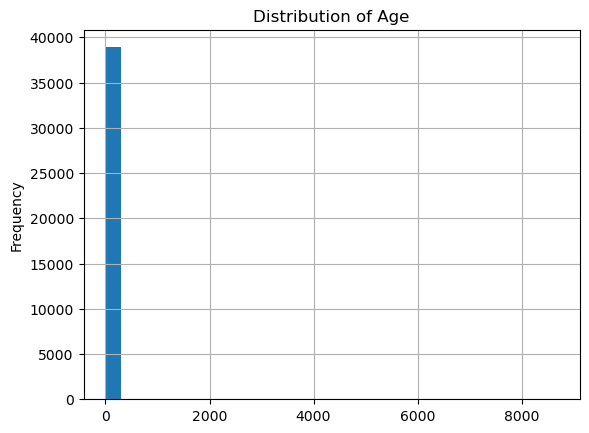

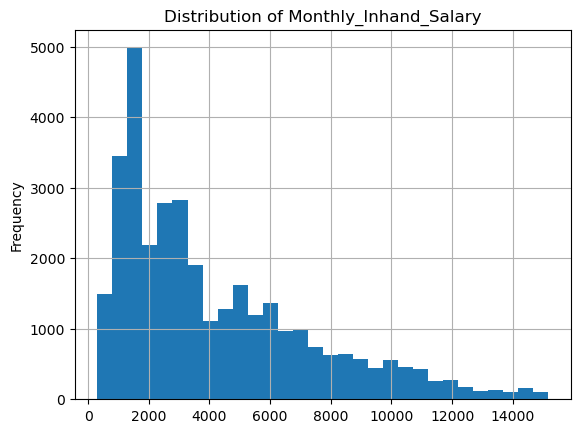

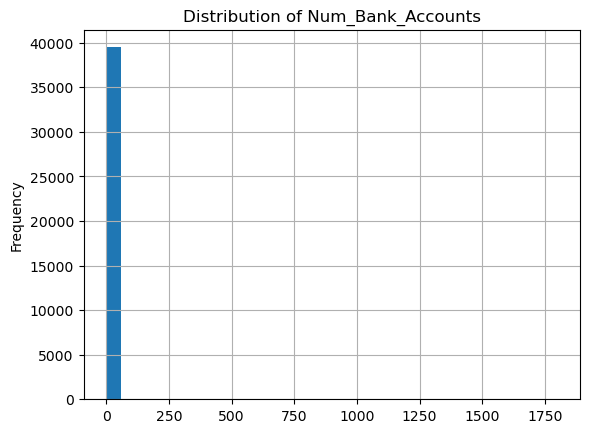

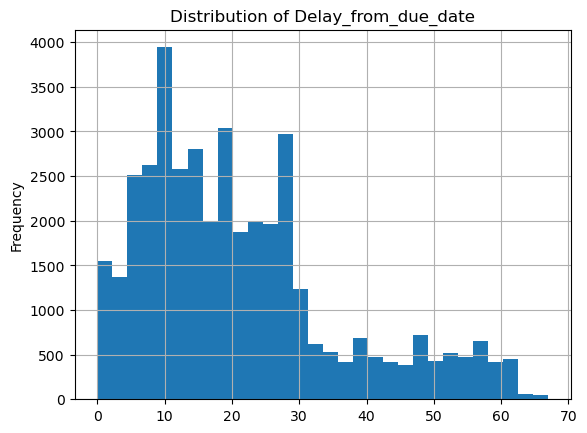

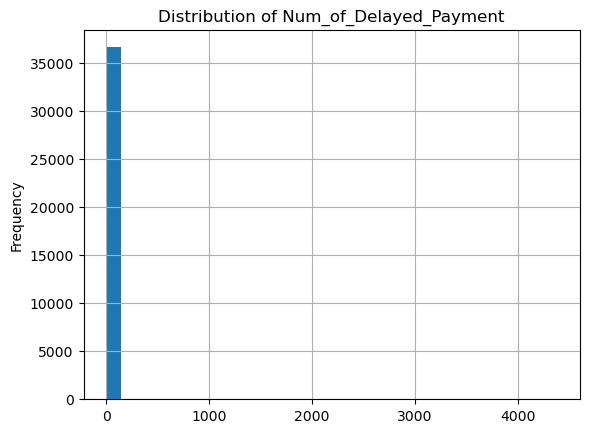

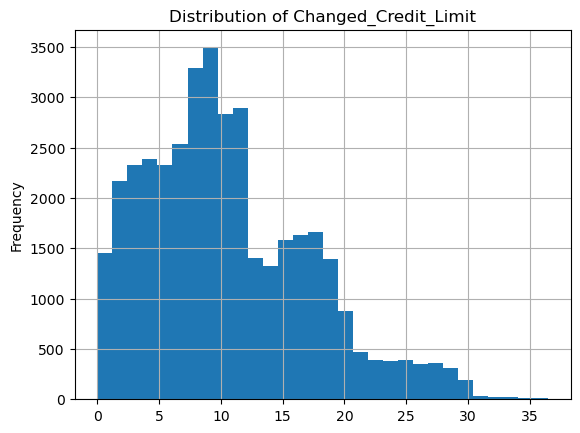

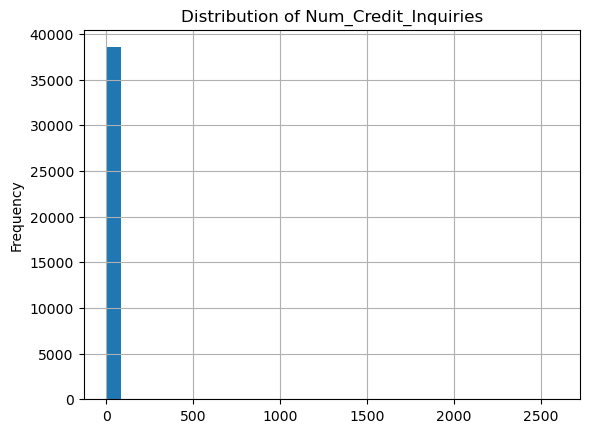

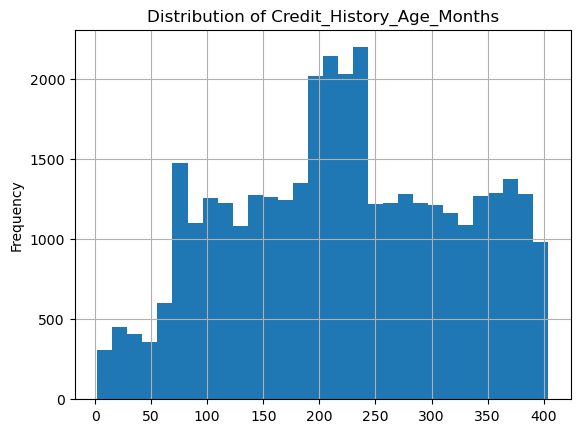

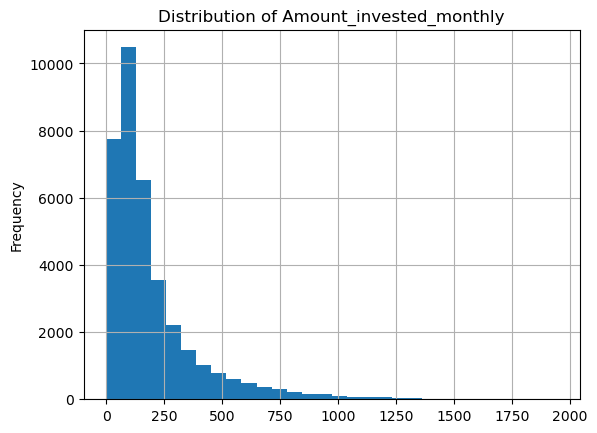

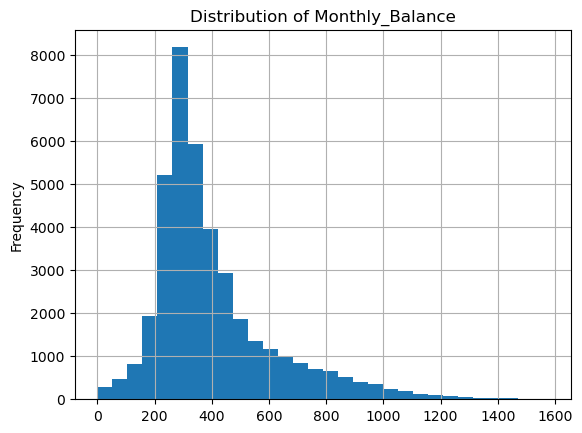

In [44]:
columns = ['Age', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_History_Age_Months', 'Amount_invested_monthly', 'Monthly_Balance']

for i in columns:
    X_train[i].dropna().hist(bins = 30)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {i}")
    plt.show()

## Boxplot

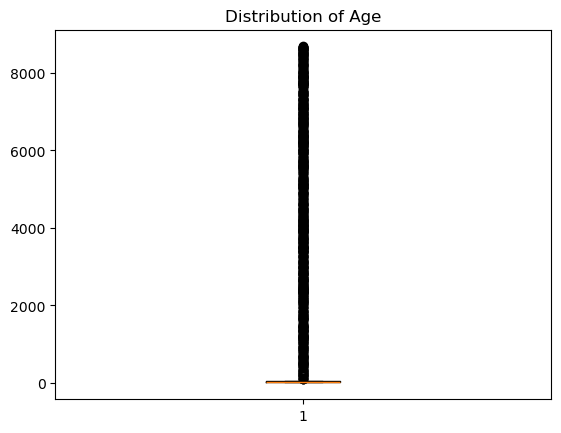

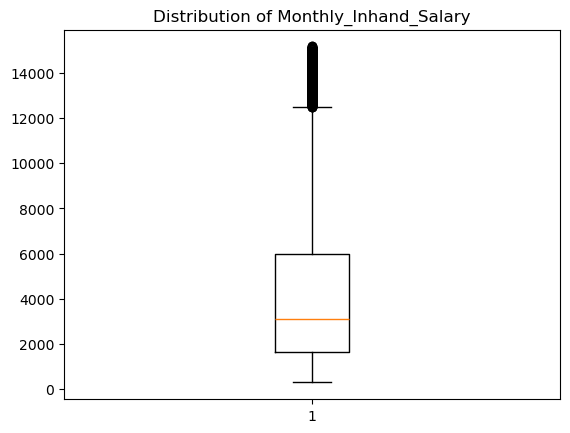

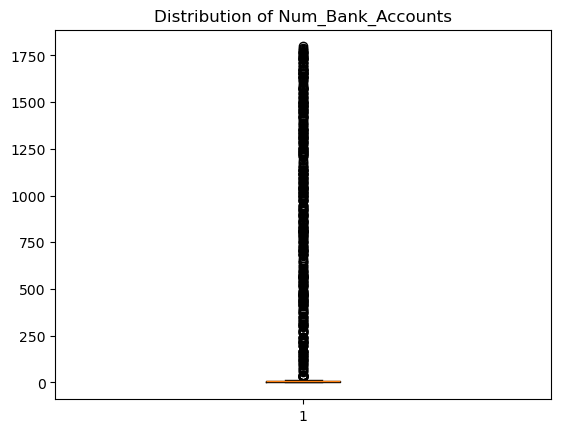

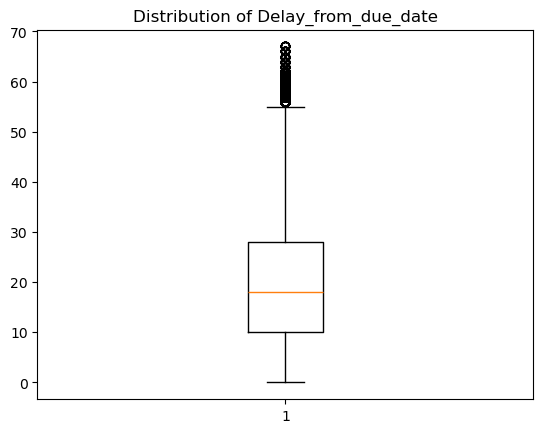

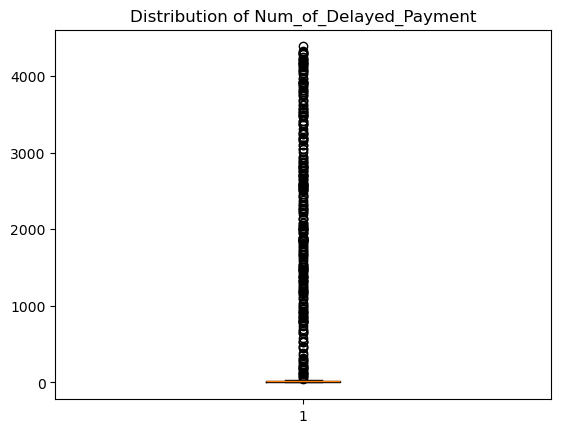

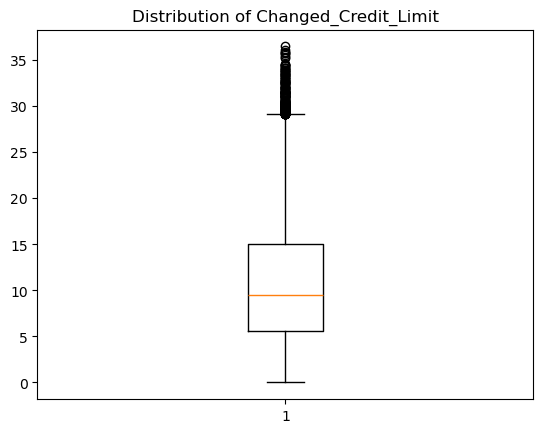

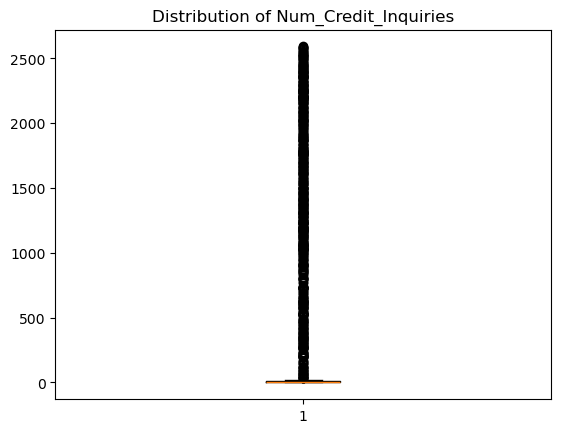

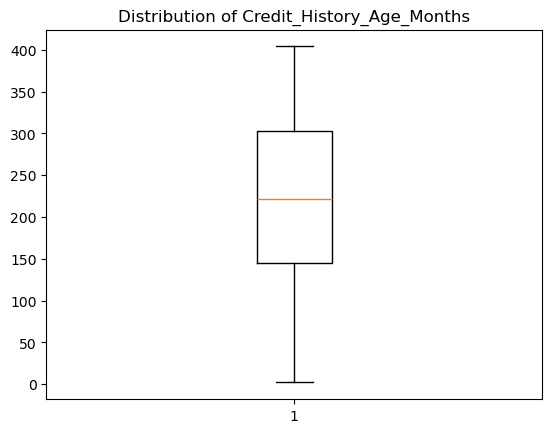

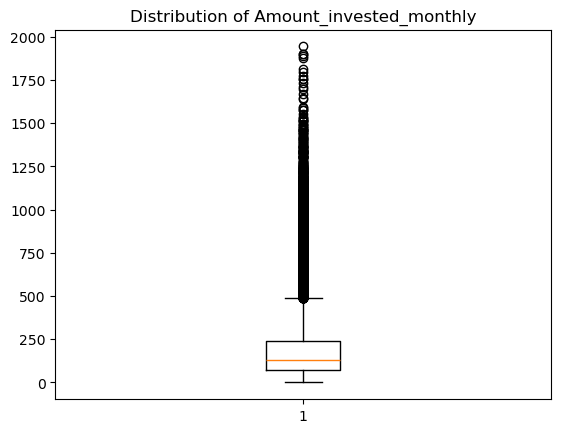

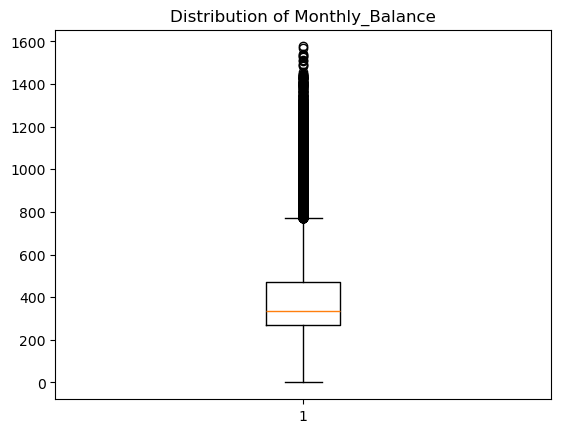

In [45]:
for i in columns:
    plt.boxplot(X_train[i].dropna())
    plt.title(f"Distribution of {i}")
    plt.show()

Things to do:
1. Fill the null values with median
2. Do winsorize with quantile 0.99 for columns that don't have least extreme value and 0.95 for those having many extreme value
3. Do them all only in training data

## Imputation and Winsor

The column Monthly Inhand Salary has to be handled with median because of the right skewed data. Although there are some outliers, there are no extreme outlier so I'll keep the outlier.

In [46]:
for i in columns:
    median_val = X_train[i].median()
    X_train[i] = X_train[i].fillna(median_val)
    X_test[i] = X_test[i].fillna(median_val)

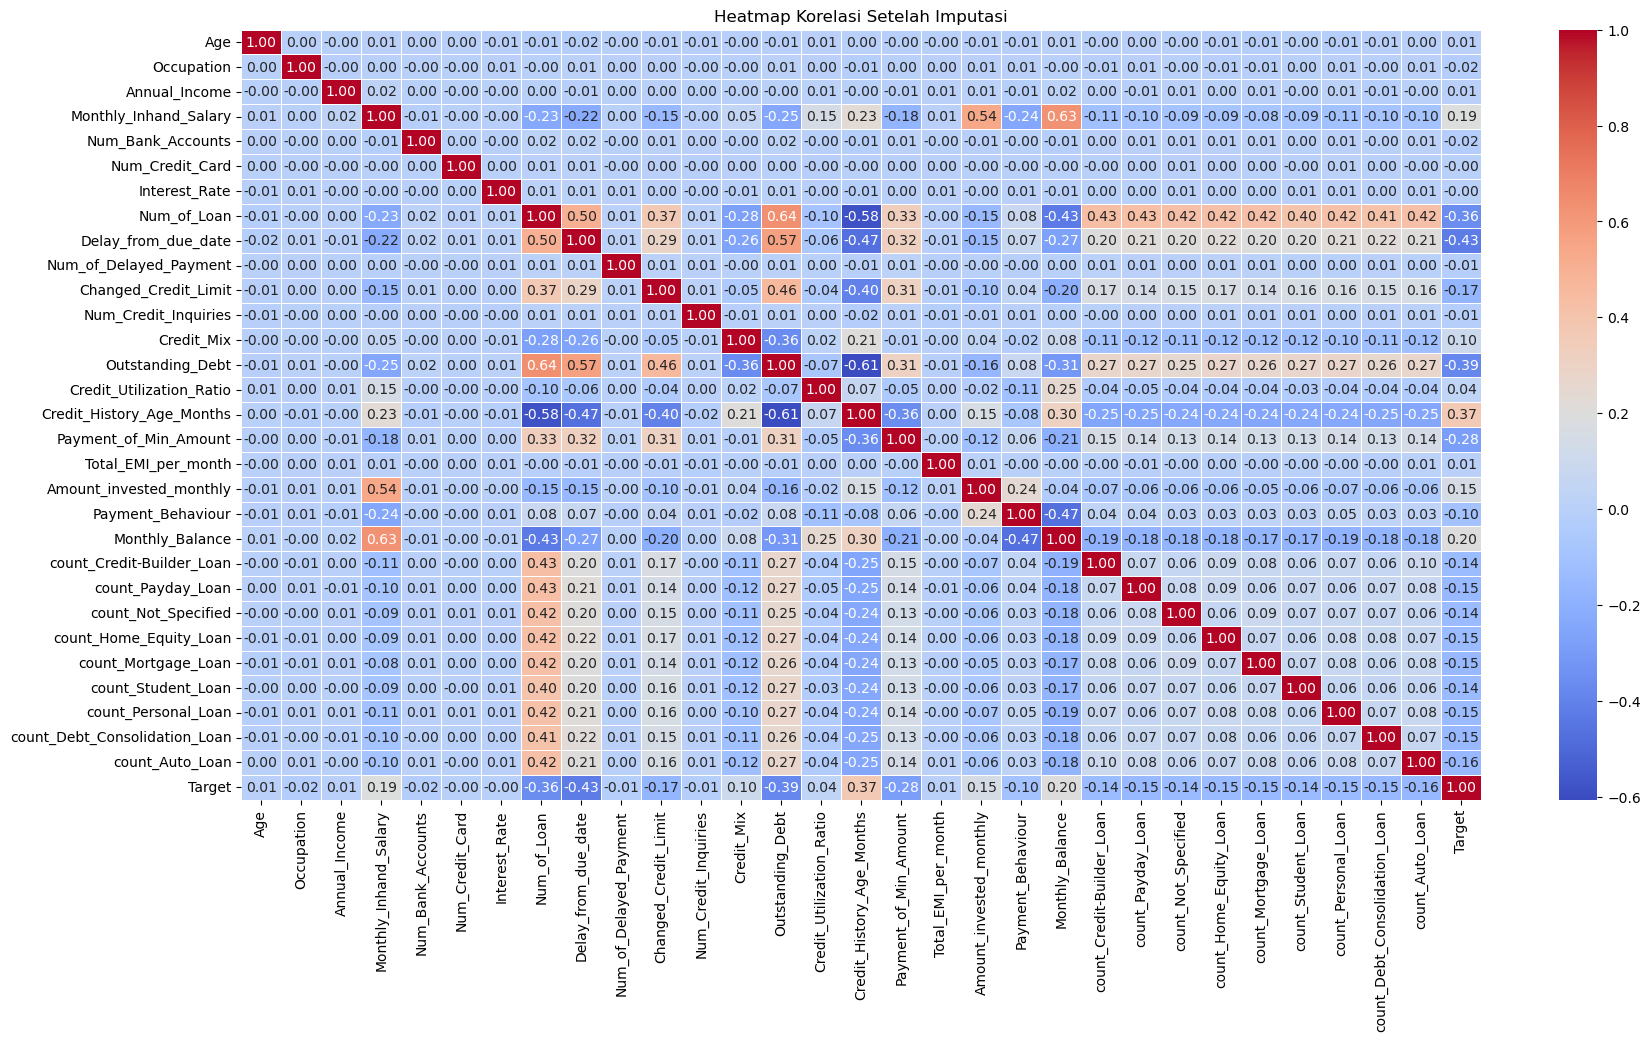

In [47]:
df_corr = X_train.copy()
df_corr['Target'] = y_train
matrix = df_corr.corr()

plt.figure(figsize=(20, 10))
sns.heatmap(matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Setelah Imputasi')
plt.show()

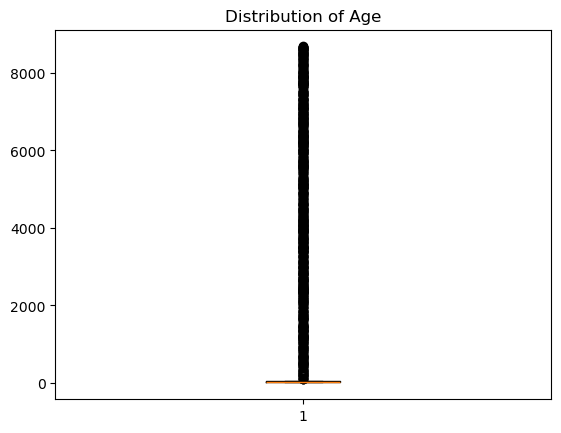

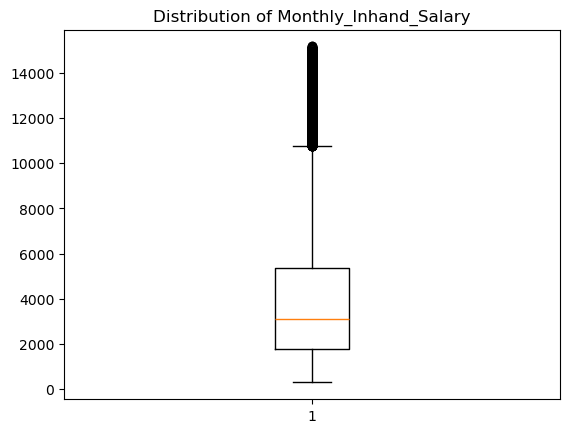

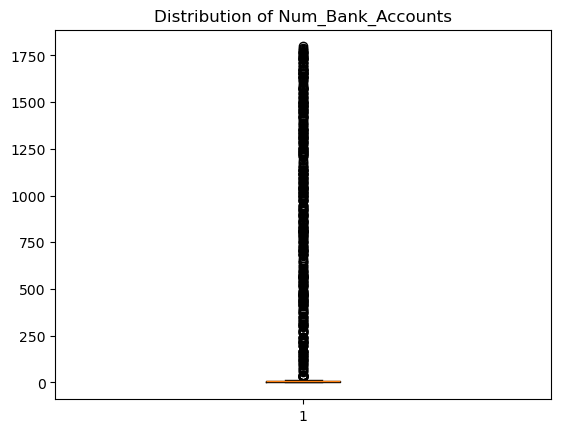

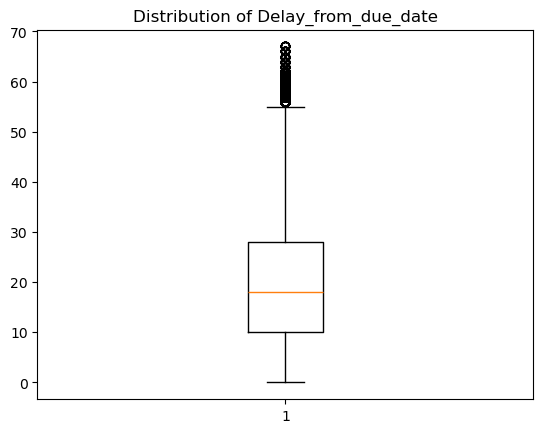

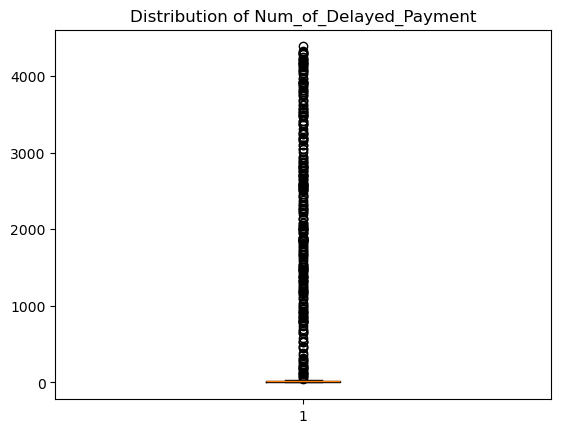

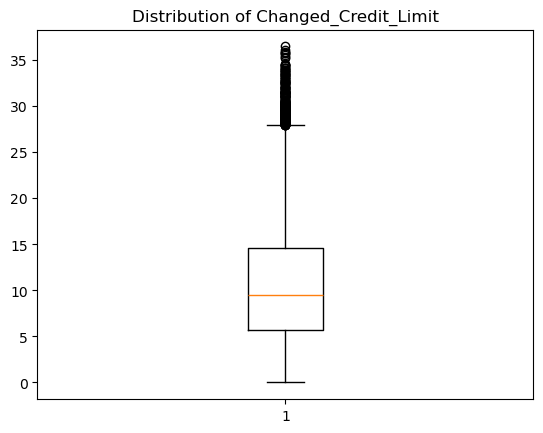

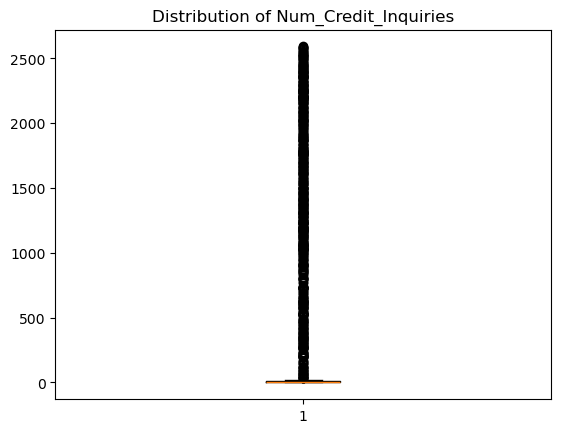

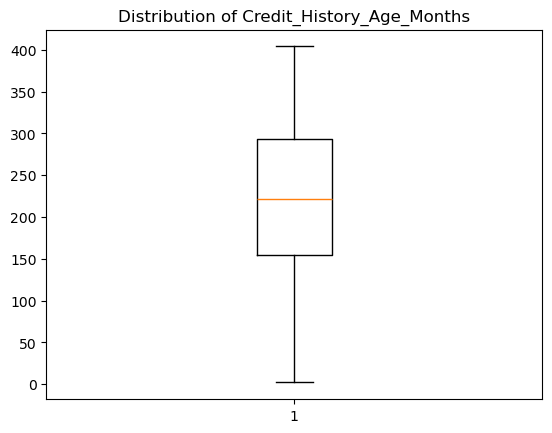

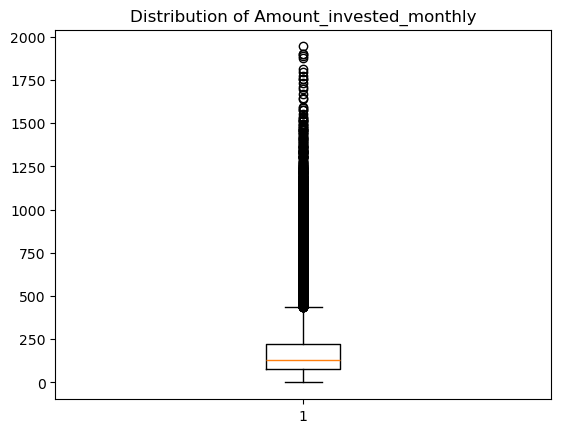

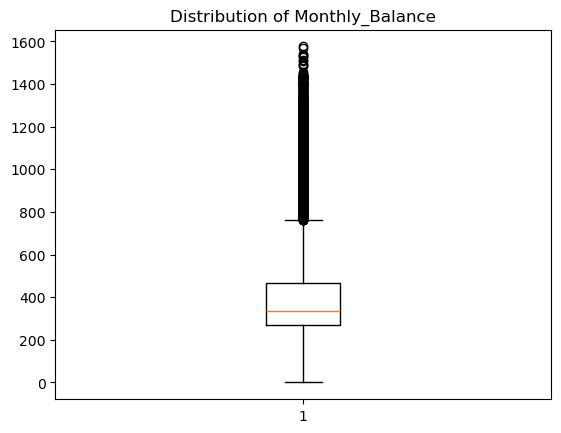

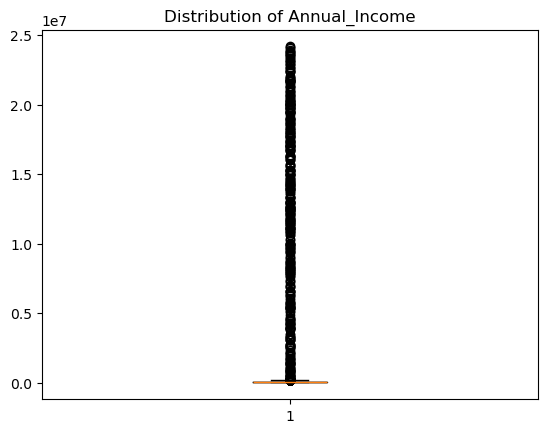

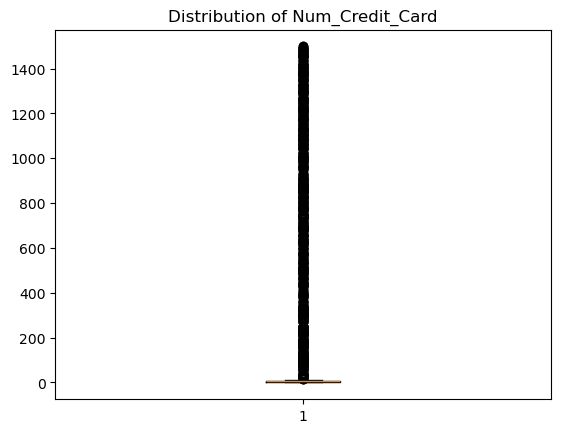

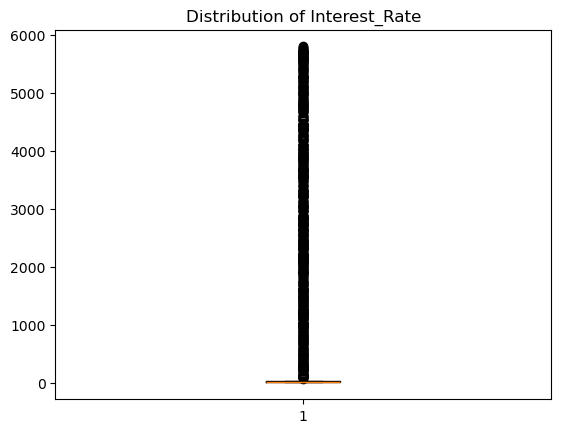

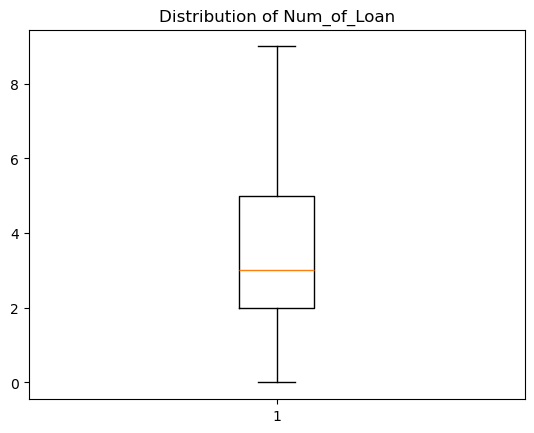

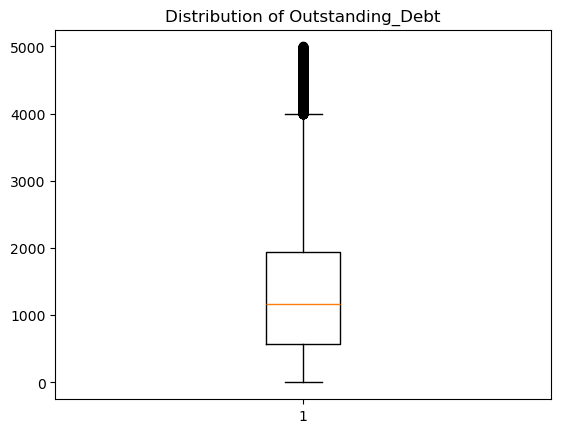

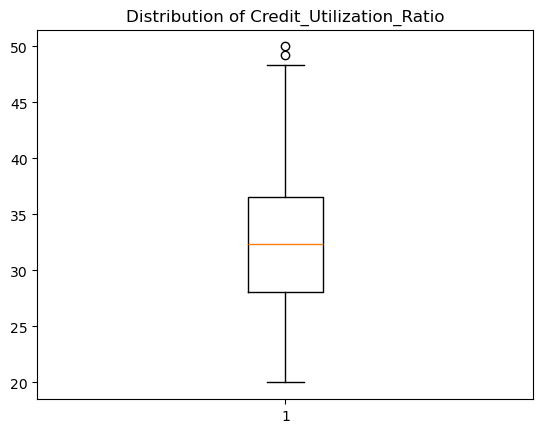

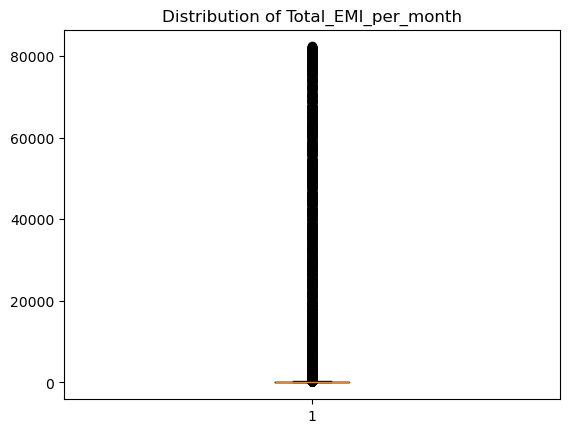

In [48]:
winsor_cols = [
    'Age', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 
    'Delay_from_due_date', 'Num_of_Delayed_Payment', 
    'Changed_Credit_Limit', 'Num_Credit_Inquiries', 
    'Credit_History_Age_Months', 'Amount_invested_monthly', 
    'Monthly_Balance', 'Annual_Income', 'Num_Credit_Card', 
    'Interest_Rate', 'Num_of_Loan', 'Outstanding_Debt', 
    'Credit_Utilization_Ratio', 'Total_EMI_per_month'
]

for i in winsor_cols:
    plt.boxplot(X_train[i].dropna())
    plt.title(f"Distribution of {i}")
    plt.show()

In [49]:
for c in winsor_cols:
    upper = X_train[c].quantile(0.99)
    X_train[c] = X_train[c].clip(upper = upper)
    X_test[c] = X_test[c].clip(upper = upper)

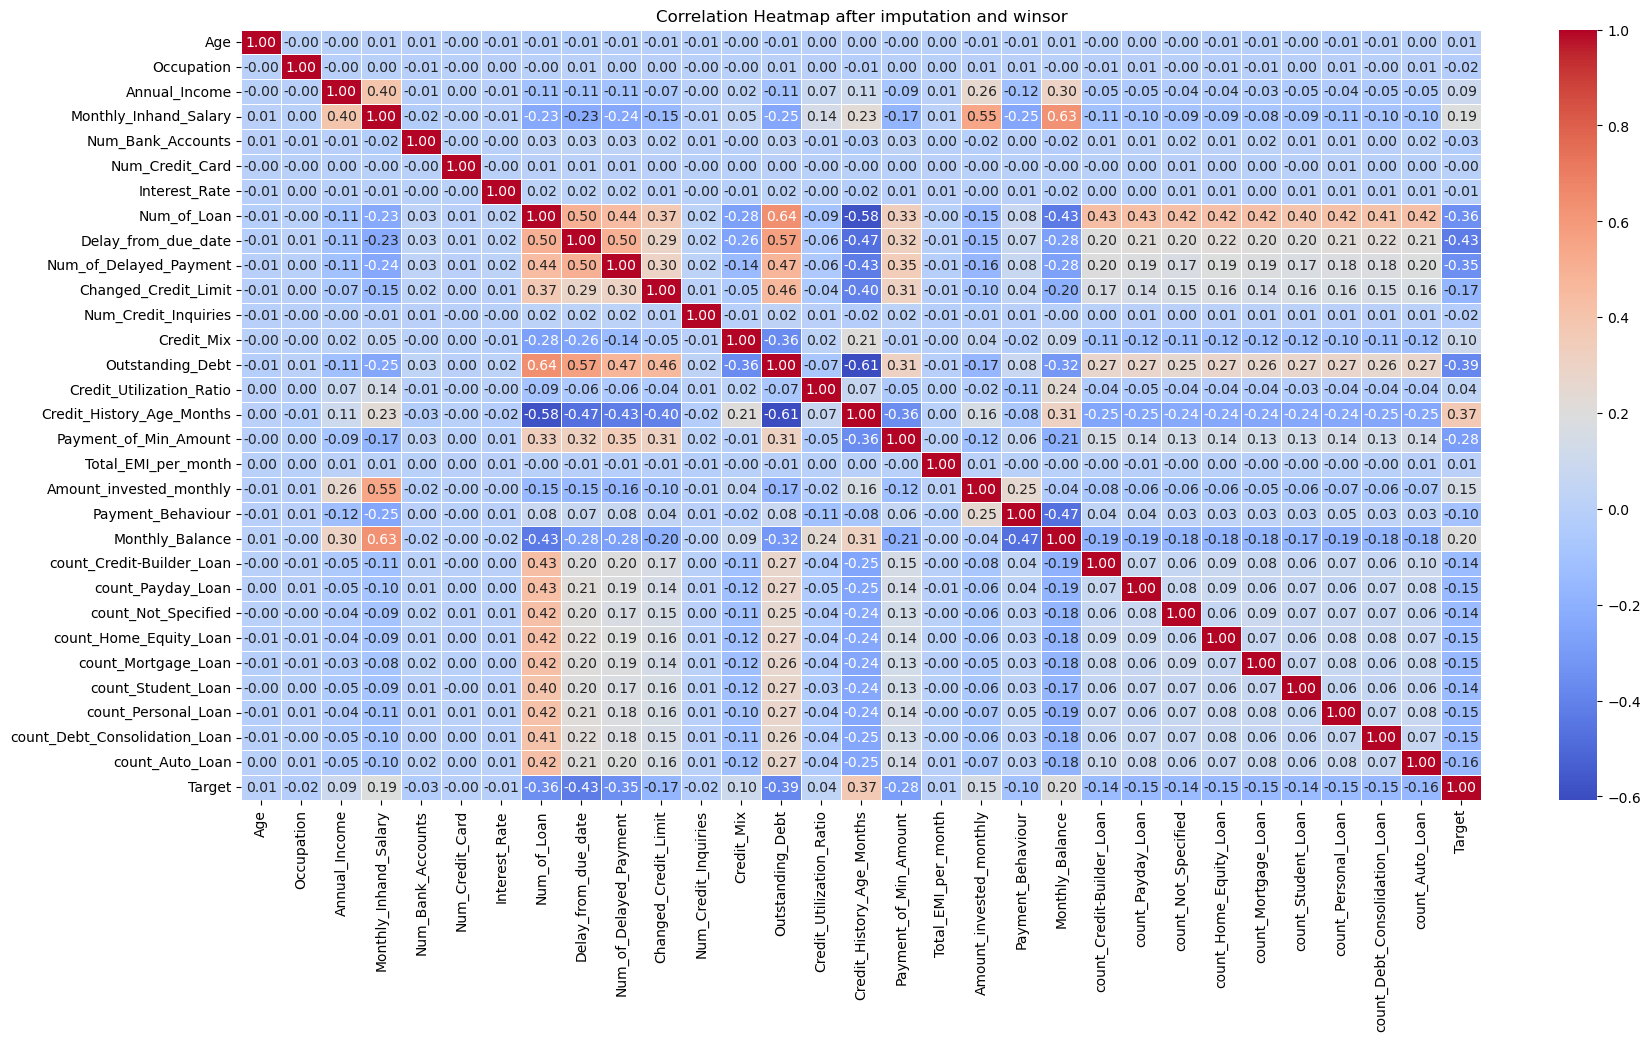

In [50]:
df_corr = X_train.copy()
df_corr['Target'] = y_train
matrix = df_corr.corr()

plt.figure(figsize=(20, 10))
sns.heatmap(matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap after imputation and winsor')
plt.show()

# Modelling

In [ ]:
model1 = RandomForestClassifier()

params = {
    "max_depth": [2, 4, 5],
    "n_estimators": [200, 300, 400, 500, 600],
    "min_samples_split": [2, 3, 4, 5, 6, 7]
}

recall = make_scorer(recall_score, average = 'macro')

grid = GridSearchCV(
    estimator = model1,
    param_grid = params,
    cv=5,
    scoring=recall,
    error_score='raise',
    n_jobs = -1
)

grid.fit(X_train, y_train)
print(f"Best param: {grid.best_params_}")
print(f"Best score: {grid.best_score_}")

In [ ]:
model_b = RandomForestClassifier(max_depth=5, n_estimators=200, min_samples_split=4)
model_b.fit(X_train, y_train)
y_pred1 = model_b.predict(X_test)
print(classification_report(y_pred1, y_test, target_names= ["Poor", "Standard", "Good"]))

              precision    recall  f1-score   support

        Poor       0.69      0.67      0.68      2985
    Standard       0.74      0.67      0.70      5831
        Good       0.37      0.56      0.45      1184

    accuracy                           0.66     10000
   macro avg       0.60      0.63      0.61     10000
weighted avg       0.68      0.66      0.66     10000



In [ ]:
model2 = XGBClassifier()
params = {
    "max_depth": [2, 4, 5],
    "n_estimators": [200, 300, 400, 500, 600],
    "learning_rate": [0.2, 0.4, 0.6, 0.8]
}

recall = make_scorer(recall_score, average = 'macro')

grid = GridSearchCV(
    estimator = model2,
    param_grid = params,
    cv=5,
    scoring=recall,
    error_score='raise',
    n_jobs = -1
)

grid.fit(X_train, y_train)
print(f"Best param: {grid.best_params_}")
print(f"Best score: {grid.best_score_}")

Best param: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 600}
Best score: 0.7213062295339032


In [ ]:
model2 = XGBClassifier(max_depth = 5, n_estimators = 600, learning_rate=0.2)
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)
print(classification_report(y_pred2, y_test, target_names= ["Poor", "Standard", "Good"]))

              precision    recall  f1-score   support

        Poor       0.75      0.76      0.76      2853
    Standard       0.79      0.77      0.78      5442
        Good       0.66      0.69      0.67      1705

    accuracy                           0.75     10000
   macro avg       0.73      0.74      0.74     10000
weighted avg       0.76      0.75      0.76     10000



In [ ]:
model_b = grid.best_estimator_
model_b.fit(X_train, y_train)
y_pred1 = model_b.predict(X_test)
#y_prob1 = model_b.predict_proba(X_test)
class_report = classification_report(y_pred1, y_test, target_names= ["Poor", "Standard", "Good"])

In [ ]:
print(class_report)

              precision    recall  f1-score   support

        Poor       0.72      0.75      0.74      2787
    Standard       0.78      0.77      0.77      5430
        Good       0.66      0.66      0.66      1783

    accuracy                           0.74     10000
   macro avg       0.72      0.72      0.72     10000
weighted avg       0.74      0.74      0.74     10000



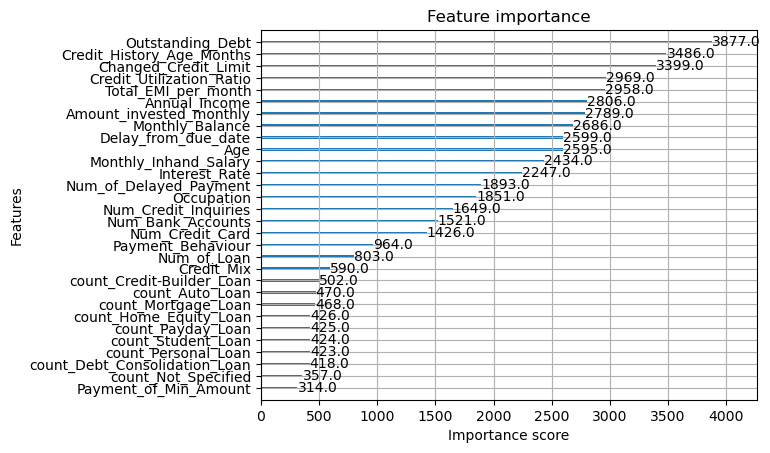

In [ ]:
plot_importance(model2)
plt.show()

From the image above, the inputs that carry the greatest importance for forecasting the target is Outstanding_Debt, Credit_History_Age_Months, and Changed_Credit_Limit.